# This Notebook contains a general analysis of all Facebook ads

In [1]:
%load_ext watermark
%watermark -v -n -m -p numpy,scipy,sklearn,pandas

import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# reload all modules every time before executing the Python code
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import os
import sys

print(f'default sys.path: {sys.path}')

PROJ_ROOT = os.path.abspath(os.path.join(os.pardir))
PROJ_ROOT = os.path.abspath(os.path.join(PROJ_ROOT, os.pardir))
sys.path.append(PROJ_ROOT)
print(f'Project root: {PROJ_ROOT}')


from utils import mpl_settings
import pandas as pd
from scipy.stats import stats
import numpy as np
from collections import Counter
from utils.dataset_utilities import load_data
from utils import config
from utils.dataset_utilities import expand_rows_spreading_spend

print(f'\nNumber of days in the considered period: {config.END_DATE - config.START_DATE}')

keywords = pd.read_csv('../../data/external/keywords.csv', header=None)
keywords = keywords[0].tolist()

mpl_settings.apply_settings()

Python implementation: CPython
Python version       : 3.10.14
IPython version      : 8.20.0

numpy  : 1.26.4
scipy  : 1.11.4
sklearn: 1.3.0
pandas : 2.2.1

Compiler    : GCC 11.2.0
OS          : Linux
Release     : 6.1.0-25-amd64
Machine     : x86_64
Processor   : 
CPU cores   : 16
Architecture: 64bit

default sys.path: ['/home/steph/Documents/code_projects/Political-Advertising-2022-AU-Federal-Election/src/notebooks', '/home/steph/miniconda3/envs/fbads/lib/python310.zip', '/home/steph/miniconda3/envs/fbads/lib/python3.10', '/home/steph/miniconda3/envs/fbads/lib/python3.10/lib-dynload', '', '/home/steph/miniconda3/envs/fbads/lib/python3.10/site-packages']
Project root: /home/steph/Documents/code_projects/Political-Advertising-2022-AU-Federal-Election

Number of days in the considered period: 92 days 00:00:00


[nltk_data] Downloading package stopwords to /home/steph/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/steph/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /home/steph/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [2]:
# The following data loading assumes that you have already parsed the raw data using the dataset_creation.py script
file_path = '../../data/processed/2022_aus_elections_mar_to_may.csv'
df = load_data(file_path)

In [3]:
df.columns

Index(['ad_creation_time', 'ad_creative_body', 'ad_creative_link_caption',
       'ad_creative_link_title', 'ad_delivery_start_time', 'ad_snapshot_url',
       'currency', 'demographic_distribution', 'funding_entity', 'page_id',
       'page_name', 'region_distribution', 'id', 'ad_creative_body_id',
       'mean_spend', 'mean_impressions', 'cost_per_impression', 'languages',
       'impressions.lower_bound', 'impressions.upper_bound',
       'spend.lower_bound', 'spend.upper_bound', 'ad_delivery_stop_time',
       'ad_creative_link_description', 'date_first_detected', 'party', 'state',
       'electorate', 'full_name', 'house_or_senate', 'organization_class',
       'organization_subclass', 'electorate_from_page_name',
       'party_from_page_name', 'state_from_page_name', 'state_from_electorate',
       'custom_body', 'stemmed_body', 'multiword_safe_lemmatized',
       'has_political_keywords', 'has_party', 'macro_party',
       'macro_party_uap'],
      dtype='object')

In [4]:
def general_stats(df):
    """This function calculates and prints general statistics about the dataset."""
    total_ads = len(df)
    unique_pages = df['page_id'].nunique()
    total_impressions = df['mean_impressions'].sum() / 1e6  # in millions
    total_spend = df['mean_spend'].sum() /1e6  # in millions
    unique_funding_entities = df['funding_entity'].nunique()
    cpi = total_spend / total_impressions * 1000
    # Print results
    print(f"In the two months leading up to the election:")
    print(f"Number of ads published: {total_ads}")
    print(f"Number of different pages used: {unique_pages}")
    print(f"Total impressions generated: {total_impressions:.2f} million")
    print(f"Total ad spend: AUD {total_spend:.2f} million")
    print(f'Unique funding entities: {unique_funding_entities}')
    print(f'Cost per thousand impressions: {cpi:.2f}')

    election_period_metrics = {
        'total_ads': total_ads,
        'unique_pages': unique_pages,
        'total_impressions_millions': total_impressions,
        'total_spend_aud': total_spend
    }

    print("\nElection period metrics dictionary:")
    print(election_period_metrics)

general_stats(df)

In the two months leading up to the election:
Number of ads published: 56224
Number of different pages used: 1821
Total impressions generated: 1329.82 million
Total ad spend: AUD 21.53 million
Unique funding entities: 1549
Cost per thousand impressions: 16.19

Election period metrics dictionary:
{'total_ads': 56224, 'unique_pages': 1821, 'total_impressions_millions': 1329.8224525, 'total_spend_aud': 21.530711531950004}


In [5]:
pak = df[df['has_political_keywords']]
pap = df[df['has_party']]

## Print the general statistics of PAK and PAP datasets
- PAK (Political Advertisements Keywords) is the larger dataset comprising all ads containing at least one of the keywords present in data/external/keywprds.csv
- PAP (Political Advertisements Parties) contains all ads that are associated with a party

In [6]:
general_stats(pak)

In the two months leading up to the election:
Number of ads published: 47503
Number of different pages used: 1685
Total impressions generated: 1114.04 million
Total ad spend: AUD 18.39 million
Unique funding entities: 1438
Cost per thousand impressions: 16.51

Election period metrics dictionary:
{'total_ads': 47503, 'unique_pages': 1685, 'total_impressions_millions': 1114.0417965, 'total_spend_aud': 18.39143777445}


In [7]:
general_stats(pap)

In the two months leading up to the election:
Number of ads published: 30767
Number of different pages used: 813
Total impressions generated: 714.31 million
Total ad spend: AUD 12.56 million
Unique funding entities: 629
Cost per thousand impressions: 17.58

Election period metrics dictionary:
{'total_ads': 30767, 'unique_pages': 813, 'total_impressions_millions': 714.312132, 'total_spend_aud': 12.5594165}


Sponsors that have been removed by the keyword filtering

In [8]:
# Unique funding entities in ads that don't have political keywords
funding_entities_no_keywords = df[~df['has_political_keywords']]['funding_entity'].unique()

# Unique funding entities in ads that have political keywords
funding_entities_with_keywords = pak['funding_entity'].unique()

# Find entities exclusively in ads without political keywords
exclusive_entities = [entity for entity in funding_entities_no_keywords if entity not in funding_entities_with_keywords]

print(len(exclusive_entities))
print(exclusive_entities)

112
['Love + Money', 'Health Studies Australia', 'SumOfUs Australia', 'Destiny Rescue', 'SBS Persian', 'City of Adelaide', 'ActionAid Australia', 'DocPlay', 'Wayside Chapel', 'AIJAC - Australia/Israel & Jewish Affairs Council', 'Canva', 'City of Greater Geraldton', nan, 'Colin Boyce MP - Member for Callide', 'Christian Medical and Dental Fellowship of Australia', 'The Benevolent Society', 'Maxwell Anthony Venn-Brown', 'Shokufeh Kavani Gherkhlo', 'Cultural Perspectives', 'World Wellness Group', 'Andrew James Hay', 'UnionsACT', 'World Transformation Movement', 'Youth Off The Streets', 'Adrian Raedel', "Women's and Girls' Emergency Centre", 'Annastacia Palaszczuk MP', 'Planet Ark Environmental Foundation', 'Andrew Charles Laming', 'Department of Regional NSW', 'UNSW Sydney', 'Costas A Vasili', 'James Lloyd Nicholas Mullan', 'SBS Korean', 'Michael Jones, Solicitor', 'Sydney Fibroid Clinic', 'SBS French', 'Australian Cyber Security Centre', 'Tony Latter ', 'Weleda Australa', 'Hong Kong Econ

In [9]:
# Helper function to convert duration to days
def duration_to_days(start, end):
    return (pd.to_datetime(end) - pd.to_datetime(start)).dt.total_seconds() / (24 * 3600)

# Individual ads statistics
def compute_individual_ad_stats(df):
    # Calculate ad duration
    df['ad_duration'] = duration_to_days(df['ad_delivery_start_time'], df['ad_delivery_stop_time'])
    
    # Impressions statistics
    impressions_avg = df['mean_impressions'].mean()
    impressions_median = df['mean_impressions'].median()
    impressions_max = df['mean_impressions'].max()
    
    # Cost statistics
    cost_avg = df['mean_spend'].mean()
    cost_median = df['mean_spend'].median()
    cost_max = df['mean_spend'].max()
    
    # Duration statistics
    duration_avg = df['ad_duration'].mean()
    duration_median = df['ad_duration'].median()
    duration_max = df['ad_duration'].max()
    
    # Efficiency statistics
    df['efficiency'] = df['mean_impressions'] / df['mean_spend']
    efficiency_avg = df['efficiency'].mean()
    efficiency_median = df['efficiency'].median()
    efficiency_max = df['efficiency'].max()
    
    # Language distribution
    language_dist = df['languages'].value_counts()
    english_ads = language_dist.get('en', 0)
    chinese_ads = language_dist.get('zh', 0)
    arabic_ads = language_dist.get('ar', 0)
    total_ads = len(df)
    english_percentage = (english_ads / total_ads) * 100
    chinese_percentage = (chinese_ads / total_ads) * 100
    arabic_percentage = (arabic_ads / total_ads) * 100   
    
    
    return {
        'impressions_avg': impressions_avg,
        'impressions_median': impressions_median,
        'impressions_max': impressions_max,
        'cost_avg': cost_avg,
        'cost_median': cost_median,
        'cost_max': cost_max,
        'duration_avg': duration_avg,
        'duration_median': duration_median,
        'duration_max': duration_max,
        'efficiency_avg': efficiency_avg,
        'efficiency_median': efficiency_median,
        'efficiency_max': efficiency_max,
        'english_ads': english_ads,
        'english_percentage': english_percentage,
        'chinese_ads': chinese_ads,
        'chinese_percentage': chinese_percentage,
        'arabic_ads': arabic_ads,
        'arabic_percentage': arabic_percentage
    }

# Correlation Insights
def compute_correlations(df):
    
    df_clean = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['mean_spend', 'mean_impressions', 'ad_duration'])
    def safe_pearsonr(x, y):
        if len(x) > 1:  # Ensure we have at least 2 valid pairs of data points
            return stats.pearsonr(x, y)
        else:
            return (np.nan, np.nan)  # Return NaN if not enough data
    
    # Expense vs Impressions
    corr_expense_impressions, p_expense_impressions = safe_pearsonr(df_clean['mean_spend'], df_clean['mean_impressions'])
    
    # Duration vs Expense
    corr_duration_expense, p_duration_expense = safe_pearsonr(df_clean['ad_duration'], df_clean['mean_spend'])
    
    # Duration vs Impressions
    corr_duration_impressions, p_duration_impressions = safe_pearsonr(df_clean['ad_duration'], df_clean['mean_impressions'])
    
    return {
        'expense_impressions': {
            'correlation': corr_expense_impressions,
            'p_value': p_expense_impressions
        },
        'duration_expense': {
            'correlation': corr_duration_expense,
            'p_value': p_duration_expense
        },
        'duration_impressions': {
            'correlation': corr_duration_impressions,
            'p_value': p_duration_impressions
        }
    }

# Funding Entities Strategies
def compute_funding_entity_stats(df):
    entity_stats = df.groupby('funding_entity').agg({
        'id': 'count',
        'mean_spend': 'sum',
        'mean_impressions': 'sum'
    }).reset_index()
    
    entity_stats['efficiency'] = entity_stats['mean_impressions'] / entity_stats['mean_spend']
    
    return {
        'ads_per_sponsor_avg': entity_stats['id'].mean(),
        'ads_per_sponsor_median': entity_stats['id'].median(),
        'ads_per_sponsor_max': entity_stats['id'].max(),
        'spend_per_sponsor_avg': entity_stats['mean_spend'].mean(),
        'spend_per_sponsor_median': entity_stats['mean_spend'].median(),
        'spend_per_sponsor_max': entity_stats['mean_spend'].max(),
        'impressions_per_sponsor_avg': entity_stats['mean_impressions'].mean(),
        'impressions_per_sponsor_median': entity_stats['mean_impressions'].median(),
        'impressions_per_sponsor_max': entity_stats['mean_impressions'].max(),
        'efficiency_per_sponsor_avg': entity_stats['efficiency'].mean(),
        'efficiency_per_sponsor_median': entity_stats['efficiency'].median()
    }

# Temporal Trends
def compute_temporal_trends(df):
    df = df[df['ad_delivery_stop_time'] <= config.ELECTION_DAY]
    expanded_df = pd.concat([expand_rows_spreading_spend(row) for index, row in df.iterrows()])
    daily_stats = expanded_df.groupby('date').agg({
        'ad_id': 'count', # it's called ad_id but it contains the count of the ads
        'mean_spend': 'sum',
        'mean_impressions': 'sum'
    }).reset_index()
    
    # Mann-Kendall test for trend in daily ad creation
    mk_result = stats.kendalltau(daily_stats['date'], daily_stats['ad_id']) # test the increasing trend
    
    # Correlation between daily ad creation, expenditure, and views
    corr_creation_expenditure = daily_stats['ad_id'].corr(daily_stats['mean_spend'])
    corr_creation_views = daily_stats['ad_id'].corr(daily_stats['mean_impressions'])
    
    return {
        'mk_statistic': mk_result.correlation,
        'mk_pvalue': mk_result.pvalue,
        'corr_creation_expenditure': corr_creation_expenditure,
        'corr_creation_views': corr_creation_views
    }

# Run all analyses
individual_stats = compute_individual_ad_stats(pak)
correlation_insights = compute_correlations(pak)
funding_entity_stats = compute_funding_entity_stats(pak)
temporal_trends = compute_temporal_trends(pak)

# Print results
print("Individual Ad Statistics:")
print(individual_stats)
print("\nCorrelation Insights:")
print(correlation_insights)
print("\nFunding Entity Statistics:")
print(funding_entity_stats)
print("\nTemporal Trends:")
print(temporal_trends)

Individual Ad Statistics:
{'impressions_avg': 23452.030324400563, 'impressions_median': 4499.5, 'impressions_max': 1000000.0, 'cost_avg': 387.16371122771193, 'cost_median': 49.5, 'cost_max': 137499.5, 'duration_avg': 8.0897627518262, 'duration_median': 6.0, 'duration_max': 89.0, 'efficiency_avg': 67.53673967980095, 'efficiency_median': 50.07010014306152, 'efficiency_max': 4319.504253056885, 'english_ads': 46949, 'english_percentage': 98.83375786792413, 'chinese_ads': 105, 'chinese_percentage': 0.2210386712418163, 'arabic_ads': 37, 'arabic_percentage': 0.07788981748521147}

Correlation Insights:
{'expense_impressions': {'correlation': 0.7182611102050002, 'p_value': 0.0}, 'duration_expense': {'correlation': 0.09630578750226138, 'p_value': 2.9216180517184898e-98}, 'duration_impressions': {'correlation': 0.1698330453271492, 'p_value': 2.808153129899171e-304}}

Funding Entity Statistics:
{'ads_per_sponsor_avg': 33.009735744089014, 'ads_per_sponsor_median': 6.0, 'ads_per_sponsor_max': 3239, 

mk_statistic 0.92 suggests a very strong increasing trend.

extremely small p-value (much smaller than the common significance levels like 0.05 or 0.01).
It indicates that the trend observed is statistically significant.

In [10]:
def analyze_political_ads(df):
    # Convert date columns to datetime
    date_columns = ['ad_creation_time', 'ad_delivery_start_time', 'ad_delivery_stop_time']
    for col in date_columns:
        df[col] = pd.to_datetime(df[col])

    # Calculate ad duration in days
    df['ad_duration'] = (df['ad_delivery_stop_time'] - df['ad_delivery_start_time']).dt.total_seconds() / (24 * 3600)

    # 1. Funding entity with max impressions
    max_impressions = df.loc[df['mean_impressions'].idxmax()]
    print(f"1. Funding entity with max impressions: {max_impressions['funding_entity']}")
    print(f"   Max impressions: {max_impressions['mean_impressions']:.0f}")

    # 2. Funding entity with most expensive ad
    most_expensive = df.loc[df['mean_spend'].idxmax()]
    print(f"\n2. Funding entity with most expensive ad: {most_expensive['funding_entity']}")
    print(f"   Highest spend: {most_expensive['mean_spend']:.2f} {most_expensive['currency']}")

    # 3. Funding entity with longest running ad
    longest_running = df.loc[df['ad_duration'].idxmax()]
    print(f"\n3. Funding entity with longest running ad: {longest_running['funding_entity']}")
    print(f"   Longest duration: {longest_running['ad_duration']:.2f} days")

    # 4. Funding entity with highest impressions per dollar
    df['impressions_per_dollar'] = df['mean_impressions'] / df['mean_spend']
    highest_efficiency = df.loc[df['impressions_per_dollar'].idxmax()]
    print(f"\n4. Funding entity with highest impressions per dollar: {highest_efficiency['funding_entity']}")
    print(f"   Highest efficiency: {highest_efficiency['impressions_per_dollar']:.2f} impressions per {highest_efficiency['currency']}")

    # 5. Funding entity publishing the largest amount of ads
    ad_counts = df['funding_entity'].value_counts()
    most_ads = ad_counts.index[0]
    print(f"\n5. Funding entity publishing the largest amount of ads: {most_ads}")
    print(f"   Number of ads: {ad_counts[most_ads]}")

    # 6. Funding entity achieving the largest number of total impressions
    total_impressions = df.groupby('funding_entity')['mean_impressions'].sum()
    largest_total_impressions = total_impressions.idxmax()
    print(f"\n6. Funding entity achieving the largest number of total impressions: {largest_total_impressions}")
    print(f"   Total impressions: {total_impressions[largest_total_impressions]:.0f}")


analyze_political_ads(pap) # pap or pak

1. Funding entity with max impressions: United Australia Party
   Max impressions: 1000000

2. Funding entity with most expensive ad: United Australia Party
   Highest spend: 137499.50 AUD

3. Funding entity with longest running ad: Ross Taylor for Longman
   Longest duration: 83.00 days

4. Funding entity with highest impressions per dollar: Victorian Labor
   Highest efficiency: 1111.10 impressions per AUD

5. Funding entity publishing the largest amount of ads: Australian Labor Party
   Number of ads: 3359

6. Funding entity achieving the largest number of total impressions: Australian Labor Party
   Total impressions: 121615321


## Analysis of spend on terms in PAK and PAP
NOTE: This is not included in the paper since we deemed the outcomes to not be interesting enough

In [11]:
has_keywords_not_party = pak['has_political_keywords'] & ~pak['has_party']
pak['has_keywords_not_party'] = has_keywords_not_party
has_keywords_not_party_df = pak[has_keywords_not_party]

has_keyword_and_party = pak['has_political_keywords'] & pak['has_party']
pak['has_keyword_and_party'] = has_keyword_and_party
has_keywords_and_party_df = pak[has_keyword_and_party]

combined = has_keywords_not_party | has_keyword_and_party

combined_df = pak[combined]


# print size of each dataset
print(f'has_keywords_not_party_df: {has_keywords_not_party_df.shape[0]}')
print(f'has_keywords_and_party_df: {has_keywords_and_party_df.shape[0]}')
print(f'combined_df: {combined_df.shape[0]}')
# print how many times has_keywords_and_party_df is bigger than has_keywords_not_party_df
print(f'has_keywords_and_party_df is {has_keywords_and_party_df.shape[0] / has_keywords_not_party_df.shape[0]:.2f} times bigger than has_keywords_not_party_df')


has_keywords_not_party_df: 18872
has_keywords_and_party_df: 28631
combined_df: 47503
has_keywords_and_party_df is 1.52 times bigger than has_keywords_not_party_df


In [12]:
# total amount spent on has_keywords_not_party_df
total_spent_not_party = has_keywords_not_party_df['mean_spend'].sum()
print(f'Total spent on has_keywords_not_party_df: {total_spent_not_party}')
# total amount spent on has_keywords_and_party_df
total_spent_party = has_keywords_and_party_df['mean_spend'].sum()
print(f'Total spent on has_keywords_and_party_df: {total_spent_party}')
# print how many times total_spent_party is bigger than total_spent_not_party
print(f'Total spent on has_keywords_and_party_df is {total_spent_party / total_spent_not_party:.2f} times bigger than total_spent_not_party')

Total spent on has_keywords_not_party_df: 6715403.274449999
Total spent on has_keywords_and_party_df: 11676034.5
Total spent on has_keywords_and_party_df is 1.74 times bigger than total_spent_not_party


In [13]:
print(f"has_keywords: {pak[pak['has_political_keywords']].shape[0]}")

has_keywords: 47503


In [14]:
def find_top_n_words(df, column_name, n):
    # Combine all words from the specified column into a single list
    all_words = df[column_name].str.split().explode().tolist()
    
    # Count the frequency of each word
    word_counts = Counter(all_words)
    
    # Get the N most common words
    top_n_words = word_counts.most_common(n)
    
    return top_n_words

n = 100 # Number of most common words to find
top_words = find_top_n_words(pak, 'multiword_safe_lemmatized', n)

print(f"The {n} most used words are:")
for word, count in top_words:
    print(f"{word}: {count}")

The 100 most used words are:
labor: 16780
government: 16301
vote: 15849
australia: 15019
australian: 12742
future: 11844
plan: 10972
community: 10959
scott_morrison: 9967
local: 9602
need: 9333
better: 8958
election: 8914
people: 8218
make: 8178
year: 8104
time: 7981
liberal: 7836
climate: 7764
support: 7761
help: 7747
get: 7746
party: 6607
job: 6373
candidate: 6084
green: 6009
sign: 5837
federal: 5759
u: 5697
new: 5669
care: 5658
family: 5642
action: 5430
today: 5019
one: 4929
product: 4897
like: 4587
power: 4573
change: 4464
energy: 4458
take: 4414
cost: 4333
want: 4256
economy: 4169
life: 4140
child: 4073
health: 4064
independent: 4015
protect: 3983
work: 3882
home: 3737
animal: 3668
back: 3608
risk: 3599
day: 3592
right: 3571
world: 3534
may: 3487
petition: 3445
real: 3422
million: 3417
free: 3411
business: 3385
every: 3324
national: 3319
know: 3318
stronger: 3260
strong: 3174
see: 3154
climate_change: 3099
campaign: 3061
find: 3050
say: 3020
service: 3011
description: 3001
let: 29

The 25 keywords with the highest total spend are:
['vote', 'labor', 'government', 'future', 'plan', 'election', 'liberal', 'local', 'community', 'climate', 'change', 'party', 'candidate', 'federal', 'policy', 'cut', 'nation', 'parliament', 'planet', 'environment', 'democrat', 'senator', 'announce', 'labour', 'howard']


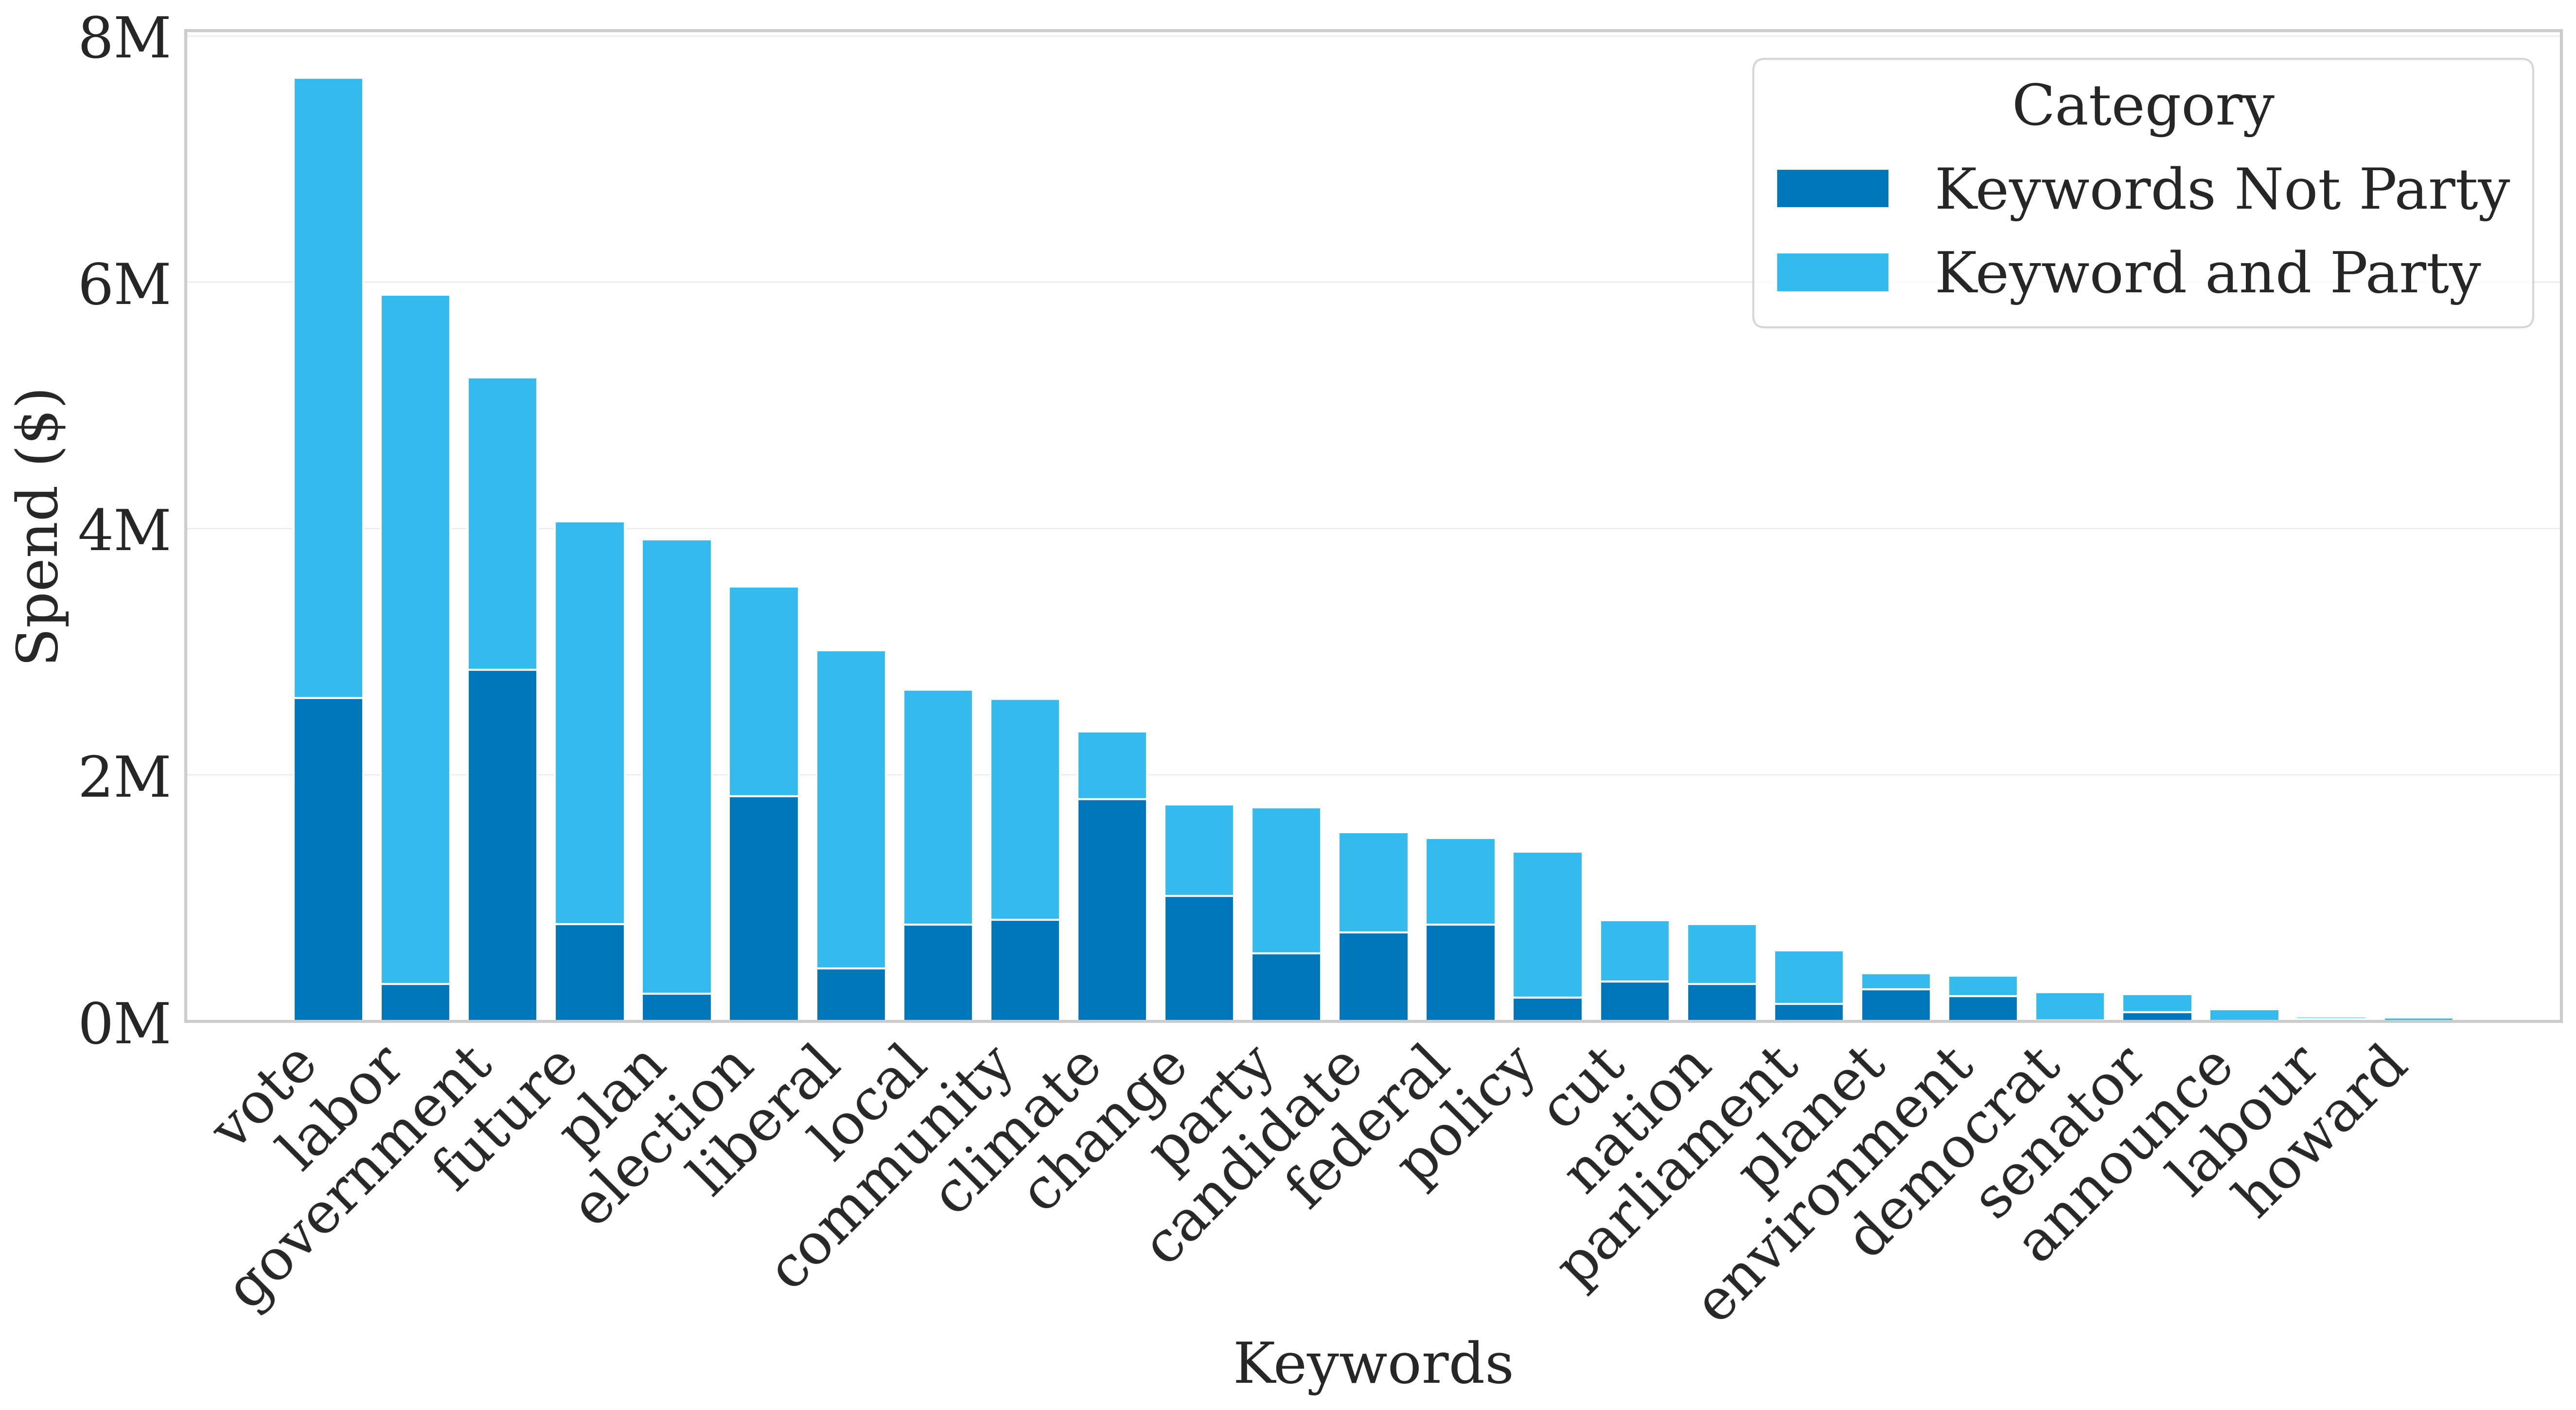

           Word  Keywords Not Party  Keyword and Party       Total
0          vote            2.627310           5.031616  7658925.50
1         labor            0.303274           5.593216  5896489.74
2    government            2.854744           2.370742  5225486.30
3        future            0.791168           3.267672  4058840.02
4          plan            0.226270           3.684544  3910814.00
5      election            1.828442           1.700651  3529093.00
6       liberal            0.430728           2.581604  3012332.00
7         local            0.785414           1.907565  2692978.28
8     community            0.824790           1.792552  2617342.22
9       climate            1.802645           0.552174  2354819.48
10       change            1.018372           0.742761  1761133.98
11        party            0.551860           1.184436  1736296.50
12    candidate            0.722405           0.814253  1536658.00
13      federal            0.784580           0.702391  148697

In [15]:
def analyze_top_spend_words(df, keywords_list, N=20, 
                            figsize=(15, 8),
                            title_size=14,
                            xlabel_size=12,
                            ylabel_size=12,
                            xtick_size=10,
                            ytick_size=10,
                            legend_title_size=12,
                            legend_text_size=10,
                            bar_text_size=8,
                            grid_alpha=0.5):
    
    # Function to calculate total spend for each word in the dataframe
    def calculate_total_word_spend(data):
        word_spend = Counter()
        for _, row in data.iterrows():
            words = str(row['multiword_safe_lemmatized']).split()
            spend = row['mean_spend']
            for word in words:
                if word in keywords_list:
                    word_spend[word] += spend
        return word_spend
    
    # Calculate total spend for each word
    total_word_spend = calculate_total_word_spend(df)
    
    # Get the N words with the highest total spend
    top_spend_words = [word for word, _ in total_word_spend.most_common(N)]
    
    print(f"The {N} keywords with the highest total spend are:")
    print(top_spend_words)
    
    # Function to calculate spend for each word in a dataframe
    def calculate_word_spend(data):
        word_spend = {word: 0 for word in top_spend_words}
        for _, row in data.iterrows():
            words = str(row['multiword_safe_lemmatized']).split()
            spend = row['mean_spend']
            for word in words:
                if word in word_spend:
                    word_spend[word] += spend
        return word_spend
    
    # Calculate spend for each category
    keywords_not_party_spend = calculate_word_spend(df[df['has_keywords_not_party']])
    keyword_and_party_spend = calculate_word_spend(df[df['has_keyword_and_party']])
    
    # Create a dataframe for plotting
    plot_data = pd.DataFrame({
        'Word': top_spend_words,
        'Keywords Not Party': [keywords_not_party_spend[word] for word in top_spend_words],
        'Keyword and Party': [keyword_and_party_spend[word] for word in top_spend_words]
    })
    
    # Sort by total spend
    plot_data['Total'] = plot_data['Keywords Not Party'] + plot_data['Keyword and Party']
    plot_data = plot_data.sort_values('Total', ascending=False)
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Convert spend to Million of dollars for readability
    plot_data['Keywords Not Party'] /= 1e6
    plot_data['Keyword and Party'] /= 1e6
    
    ax.bar(plot_data['Word'], plot_data['Keywords Not Party'], label='Keywords Not Party')
    ax.bar(plot_data['Word'], plot_data['Keyword and Party'], 
           bottom=plot_data['Keywords Not Party'], label='Keyword and Party')
    
    ax.set_xlabel('Keywords', fontsize=xlabel_size)
    ax.set_ylabel('Spend ($)', fontsize=ylabel_size)
    
    ax.tick_params(axis='x', labelsize=xtick_size)
    ax.tick_params(axis='y', labelsize=ytick_size)
    
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0f}M'))
    
    ax.legend(title='Category', title_fontsize=legend_title_size, fontsize=legend_text_size)
    
    plt.grid(True, color='lightgray', linestyle='-', linewidth=0.5, alpha=grid_alpha, axis='y')
    ax.xaxis.grid(False)
    
    plt.xticks(rotation=45, ha='right')
   
    plt.tight_layout()
    plt.show()
    
    print(plot_data)

keywords = [keyword.replace(" ", "_") for keyword in keywords]
analyze_top_spend_words(combined_df, keywords, N=25,
                        figsize=(18, 10),
                        title_size=28,
                        xlabel_size=28,
                        ylabel_size=28,
                        xtick_size=28,
                        ytick_size=28,
                        legend_title_size=28,
                        legend_text_size=28,
                        bar_text_size=10,
                        grid_alpha=0.5)